<a href="https://colab.research.google.com/github/LucasGABernardo/Lista4/blob/main/Lista4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('acessos_sistema.csv')

# Análise exploratória rápida
print("\n--- Primeiras Linhas do Arquivo de Log ---")
print(df.head())

print("\n--- Estatísticas Descritivas do Sistema ---")
print(df.describe())


--- Primeiras Linhas do Arquivo de Log ---
   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  
0                      0                            12  
1                      0                            15  
2                      0                             9  
3                      0                            18  
4                      0                            16  

--- Estatísticas Descritivas do Sistema ---
       hora_acesso  duracao_sessao_min  numero_tentativas_login  \
count    80.000000           80.000000                80.000000   
mean     10.350000           58.037500                 3

In [3]:
modelo_if = IsolationForest(contamination=0.15, random_state=42)

# Treinar o modelo e prever rótulos (-1 para anomalia, 1 para normal)
df['anomaly'] = modelo_if.fit_predict(df)

# Obter o score de decisão (scores mais negativos indicam maior facilidade de isolamento)
df['score_decisao'] = modelo_if.decision_function(df.drop(columns=['anomaly']))

# Mapear os rótulos numéricos para nomes mais fáceis de ler
df['status_acesso'] = df['anomaly'].map({1: 'Acesso Normal', -1: 'Acesso Anômalo'})

print(f"Quantidade de anomalias detectadas: {len(df[df['anomaly'] == -1])} de {len(df)} registros totais.")

Quantidade de anomalias detectadas: 12 de 80 registros totais.


In [4]:
print("--- Perfil Médio de Comportamento por Grupo ---")
analise_grupos = df.groupby('status_acesso').mean().drop(columns=['anomaly'])
print(analise_grupos)

print("\n--- Detalhe de Todos os Registros Classificados como Anômalos ---")
anomalias_detectadas = df[df['anomaly'] == -1].sort_values(by='score_decisao')
print(anomalias_detectadas[['hora_acesso', 'duracao_sessao_min', 'numero_tentativas_login', 'ip_diferente_habitual', 'quantidade_paginas_acessadas', 'score_decisao']])

--- Perfil Médio de Comportamento por Grupo ---
                hora_acesso  duracao_sessao_min  numero_tentativas_login  \
status_acesso                                                              
Acesso Anômalo    14.166667          165.083333                 2.750000   
Acesso Normal      9.676471           39.147059                 3.264706   

                ip_diferente_habitual  quantidade_paginas_acessadas  \
status_acesso                                                         
Acesso Anômalo               1.000000                     68.000000   
Acesso Normal                0.411765                     15.117647   

                score_decisao  
status_acesso                  
Acesso Anômalo      -0.028999  
Acesso Normal        0.090220  

--- Detalhe de Todos os Registros Classificados como Anômalos ---
    hora_acesso  duracao_sessao_min  numero_tentativas_login  \
71           22                 300                        1   
54           23                 300    

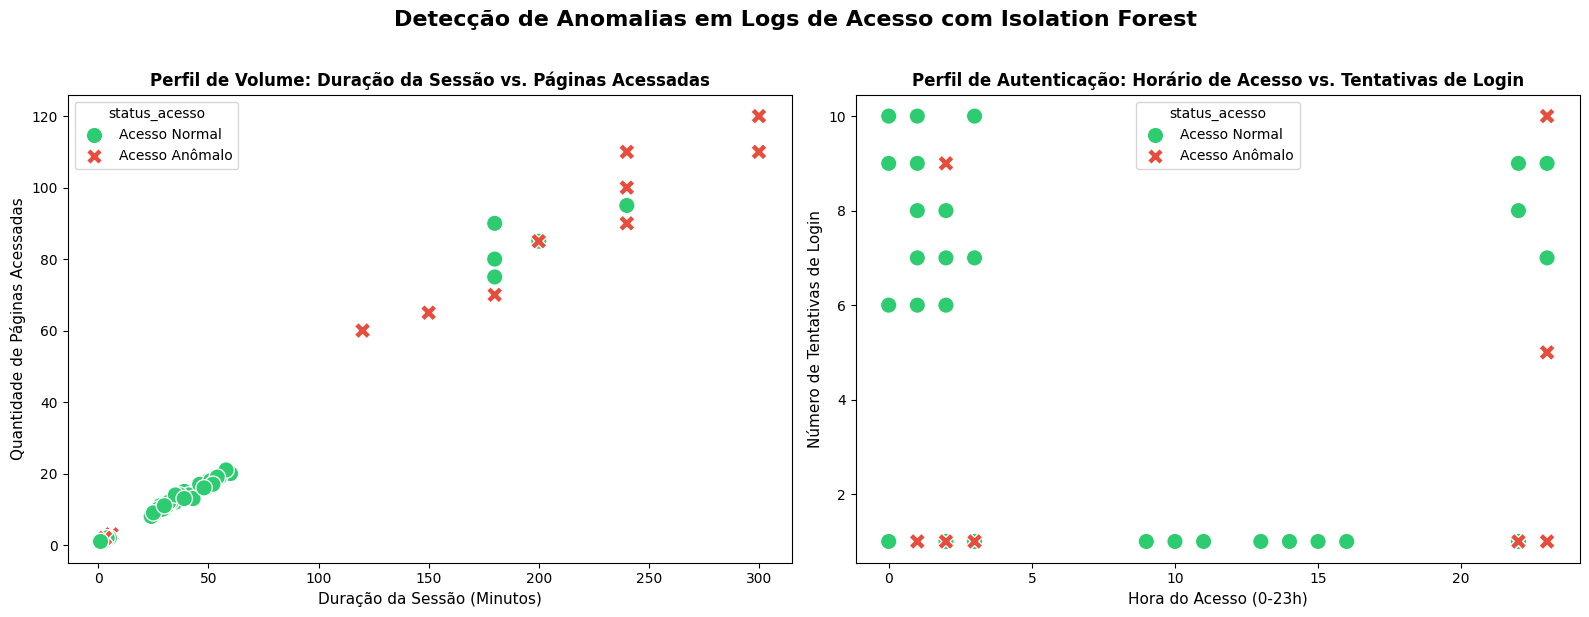

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Volume de Sessão (Duração vs. Páginas Acessadas)
sns.scatterplot(
    data=df,
    x='duracao_sessao_min',
    y='quantidade_paginas_acessadas',
    hue='status_acesso',
    palette={'Acesso Normal': '#2ecc71', 'Acesso Anômalo': '#e74c3c'},
    style='status_acesso',
    markers={'Acesso Normal': 'o', 'Acesso Anômalo': 'X'},
    s=140,
    ax=axes[0]
)
axes[0].set_title('Perfil de Volume: Duração da Sessão vs. Páginas Acessadas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duração da Sessão (Minutos)', fontsize=11)
axes[0].set_ylabel('Quantidade de Páginas Acessadas', fontsize=11)

# Subplot 2: Autenticação (Horário de Acesso vs. Tentativas de Login)
sns.scatterplot(
    data=df,
    x='hora_acesso',
    y='numero_tentativas_login',
    hue='status_acesso',
    palette={'Acesso Normal': '#2ecc71', 'Acesso Anômalo': '#e74c3c'},
    style='status_acesso',
    markers={'Acesso Normal': 'o', 'Acesso Anômalo': 'X'},
    s=140,
    ax=axes[1]
)
axes[1].set_title('Perfil de Autenticação: Horário de Acesso vs. Tentativas de Login', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora do Acesso (0-23h)', fontsize=11)
axes[1].set_ylabel('Número de Tentativas de Login', fontsize=11)

plt.suptitle('Detecção de Anomalias em Logs de Acesso com Isolation Forest', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
print("--- MÉDIA DAS CARACTERÍSTICAS POR GRUPO DETECTADO ---")
print(df.groupby('status_acesso')[['hora_acesso', 'duracao_sessao_min', 'numero_tentativas_login', 'ip_diferente_habitual', 'quantidade_paginas_acessadas']].mean())

--- MÉDIA DAS CARACTERÍSTICAS POR GRUPO DETECTADO ---
                hora_acesso  duracao_sessao_min  numero_tentativas_login  \
status_acesso                                                              
Acesso Anômalo    14.166667          165.083333                 2.750000   
Acesso Normal      9.676471           39.147059                 3.264706   

                ip_diferente_habitual  quantidade_paginas_acessadas  
status_acesso                                                        
Acesso Anômalo               1.000000                     68.000000  
Acesso Normal                0.411765                     15.117647  
